# DBSCAN — Кластеризация на основе плотности

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) определяет кластеры как плотные области в пространстве признаков, разделённые разреженными зонами. Алгоритм не требует задавать число кластеров заранее: он сам их находит, а точки в разреженных областях маркируются как **шум** (выбросы). Ключевые параметры: *eps* — радиус окрестности, *min_samples* — минимум точек для образования ядра.

**Датасет:** Wholesale Customers — годовые траты оптовых клиентов по 6 категориям товаров (440 строк, 6 признаков).

## 2. Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

df = pd.read_csv('Wholesale customers data.csv')
print("Форма датасета:", df.shape)
print("\nПервые 10 строк:")
print(df.head(10).to_string())
print("\nОписательная статистика:")
print(df.describe().round(1).to_string())
print("\nПропущенные значения:", df.isnull().sum().sum())
print("\nРаспределение Channel (1=HoReCa, 2=Retail):")
print(df['Channel'].value_counts())

Форма датасета: (440, 8)

Первые 10 строк:
   Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669   9656     7561     214              2674        1338
1        2       3   7057   9810     9568    1762              3293        1776
2        2       3   6353   8808     7684    2405              3516        7844
3        1       3  13265   1196     4221    6404               507        1788
4        2       3  22615   5410     7198    3915              1777        5185
5        2       3   9413   8259     5126     666              1795        1451
6        2       3  12126   3199     6975     480              3140         545
7        2       3   7579   4956     9426    1669              3321        2566
8        1       3   5963   3648     6192     425              1716         750
9        2       3   6006  11093    18881    1159              7425        2098

Описательная статистика:
       Channel  Region     Fresh     Milk  Grocery 

## 4. Предварительная обработка

In [3]:
# Убираем Channel и Region — категориальные, не нужны для кластеризации
feature_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
X = df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA для визуализации
pca_vis = PCA(n_components=2, random_state=42)
X_2d = pca_vis.fit_transform(X_scaled)

print("Признаки:", feature_cols)
print("Форма X_scaled:", X_scaled.shape)
print(f"PCA объясняет: {pca_vis.explained_variance_ratio_.sum()*100:.1f}% дисперсии")
print("\nДанные после масштабирования (первые 5 строк):")
print(pd.DataFrame(X_scaled[:5], columns=feature_cols).round(3).to_string())

Признаки: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Форма X_scaled: (440, 6)
PCA объясняет: 72.5% дисперсии

Данные после масштабирования (первые 5 строк):
   Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  0.053  0.524   -0.041  -0.589            -0.044      -0.066
1 -0.391  0.544    0.170  -0.270             0.086       0.089
2 -0.447  0.409   -0.028  -0.138             0.133       2.243
3  0.100 -0.624   -0.393   0.687            -0.499       0.093
4  0.840 -0.052   -0.079   0.174            -0.232       1.299


## 5. Тепловая карта корреляций

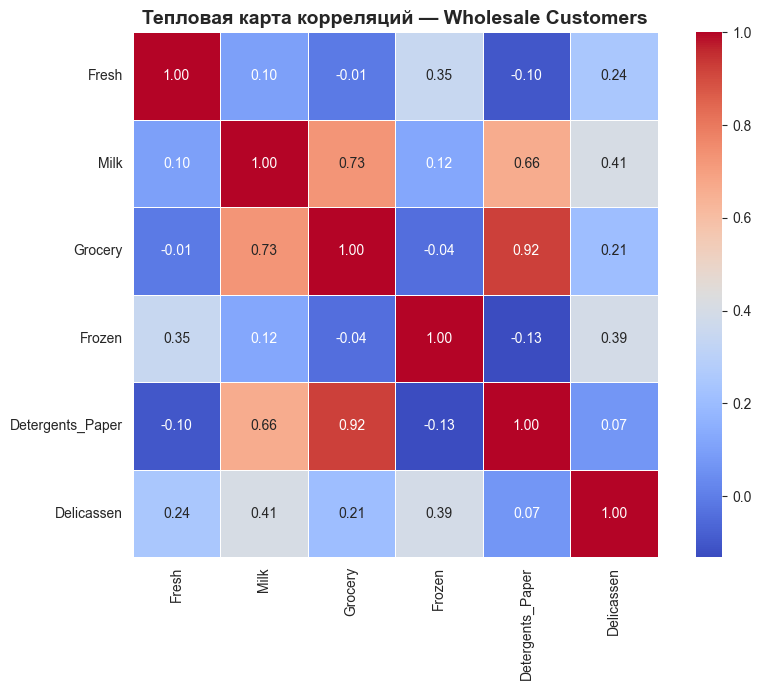

In [4]:
plt.figure(figsize=(9, 7))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5)
plt.title('Тепловая карта корреляций — Wholesale Customers', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Обучение DBSCAN — k-NN и подбор параметров

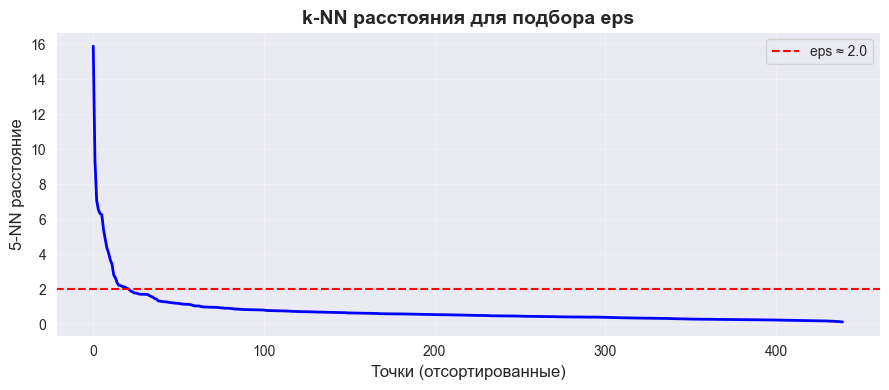

In [5]:
# k-NN для выбора eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
dist_sorted = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(9, 4))
plt.plot(dist_sorted, 'b-', linewidth=2)
plt.xlabel('Точки (отсортированные)', fontsize=12)
plt.ylabel('5-NN расстояние', fontsize=12)
plt.title('k-NN расстояния для подбора eps', fontsize=14, fontweight='bold')
plt.axhline(y=2.0, color='red', linestyle='--', label='eps ≈ 2.0')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# Grid search по параметрам
results = []
for eps in np.arange(0.5, 3.5, 0.25):
    for ms in [3, 4, 5, 7, 10]:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
        lbl = db.labels_
        n_cl  = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise = list(lbl).count(-1)
        sil   = silhouette_score(X_scaled, lbl) if n_cl >= 2 else -1
        results.append({'eps': round(eps,2), 'min_samples': ms,
                        'n_clusters': n_cl, 'noise_pct': round(noise/len(lbl)*100,1),
                        'silhouette': round(sil,4)})

res_df = pd.DataFrame(results)
print("Топ-10 по силуэту (кластеров >= 2):")
print(res_df[res_df['n_clusters'] >= 2].sort_values('silhouette', ascending=False).head(10).to_string(index=False))

Топ-10 по силуэту (кластеров >= 2):
 eps  min_samples  n_clusters  noise_pct  silhouette
1.25            3           3        6.1      0.4231
1.50            3           3        4.8      0.4213
1.00            3           2        9.3      0.4164
0.75            4           2       18.4      0.2845
0.50            4           2       36.4      0.2083
0.50            5           2       39.5      0.1958
0.75            3           2       17.0      0.0515
0.50           10           2       51.6     -0.0146
0.50            3           6       32.0     -0.0733


In [7]:
# Финальная модель — лучшие параметры из таблицы выше
best = res_df[res_df['n_clusters'] >= 2].sort_values('silhouette', ascending=False).iloc[0]
best_eps = best['eps']
best_ms  = int(best['min_samples'])
print(f"Выбраны параметры: eps={best_eps}, min_samples={best_ms}")

db = DBSCAN(eps=best_eps, min_samples=best_ms).fit(X_scaled)
labels  = db.labels_
n_cl    = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Число кластеров: {n_cl}")
print(f"Шум: {n_noise} точек ({n_noise/len(labels)*100:.1f}%)")
print(f"Силуэтный коэффициент: {silhouette_score(X_scaled, labels):.4f}")

Выбраны параметры: eps=1.25, min_samples=3
Число кластеров: 3
Шум: 27 точек (6.1%)
Силуэтный коэффициент: 0.4231


## 7. Прогнозы модели

In [8]:
df['cluster'] = labels
print("Распределение по кластерам (−1 = шум):")
print(df['cluster'].value_counts().sort_index())
print("\nСредние значения по кластерам:")
print(df.groupby('cluster')[feature_cols].mean().round(0).to_string())

Распределение по кластерам (−1 = шум):
cluster
-1     27
 0    407
 1      3
 2      3
Name: count, dtype: int64

Средние значения по кластерам:
           Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
cluster                                                                  
-1       28396.0  21624.0  24338.0  11054.0            8959.0      5952.0
 0       10999.0   4470.0   6557.0   2543.0            2320.0      1181.0
 1        3165.0  22797.0  22435.0   1183.0            8243.0      5480.0
 2        9150.0  26310.0  35105.0   4905.0           18970.0      4374.0


## 8. Графики результатов

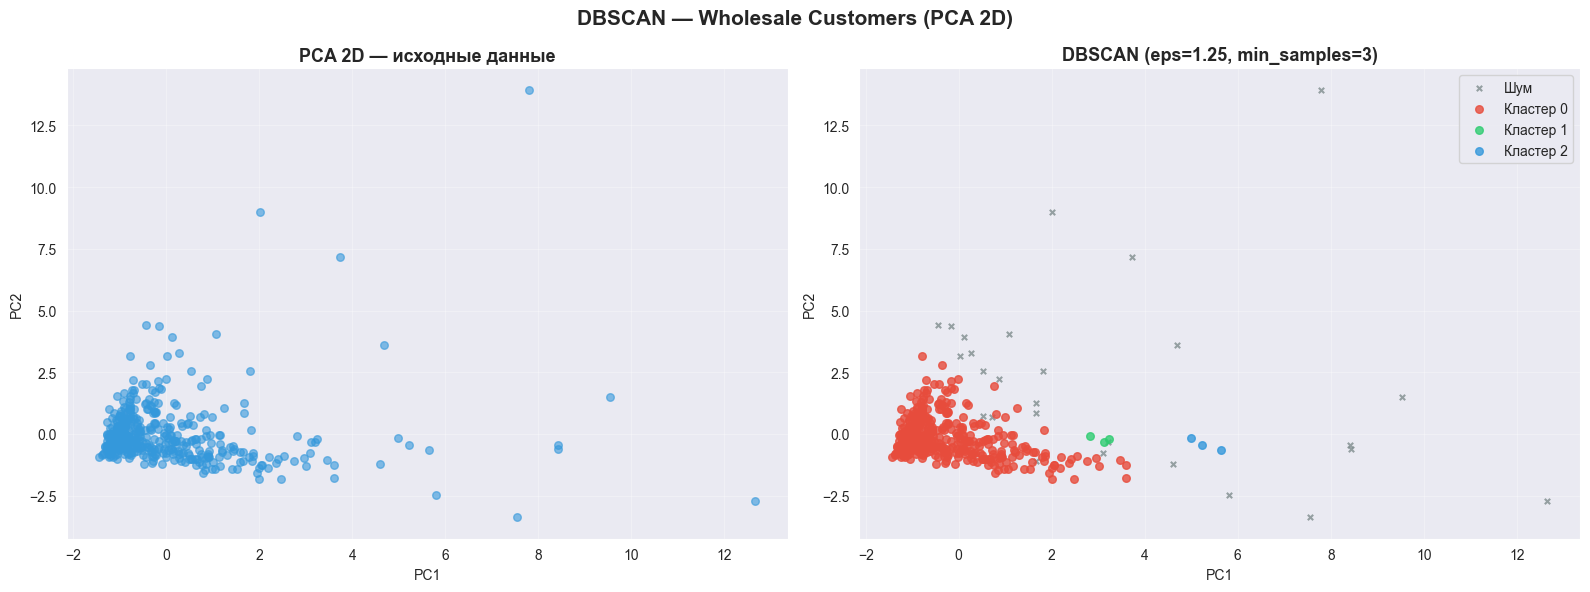

In [9]:
palette = {-1:'#7F8C8D', 0:'#E74C3C', 1:'#2ECC71', 2:'#3498DB', 3:'#F39C12', 4:'#9B59B6'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Исходные данные (без меток)
axes[0].scatter(X_2d[:,0], X_2d[:,1], c='#3498DB', s=30, alpha=0.6)
axes[0].set_title('PCA 2D — исходные данные', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# DBSCAN результат
for lbl in sorted(set(labels)):
    mask = labels == lbl
    name = f'Кластер {lbl}' if lbl >= 0 else 'Шум'
    axes[1].scatter(X_2d[mask,0], X_2d[mask,1],
                    c=palette.get(lbl,'#27AE60'), s=30 if lbl>=0 else 15,
                    alpha=0.8, marker='o' if lbl>=0 else 'x', label=name)
axes[1].set_title(f'DBSCAN (eps={best_eps}, min_samples={best_ms})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('DBSCAN — Wholesale Customers (PCA 2D)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

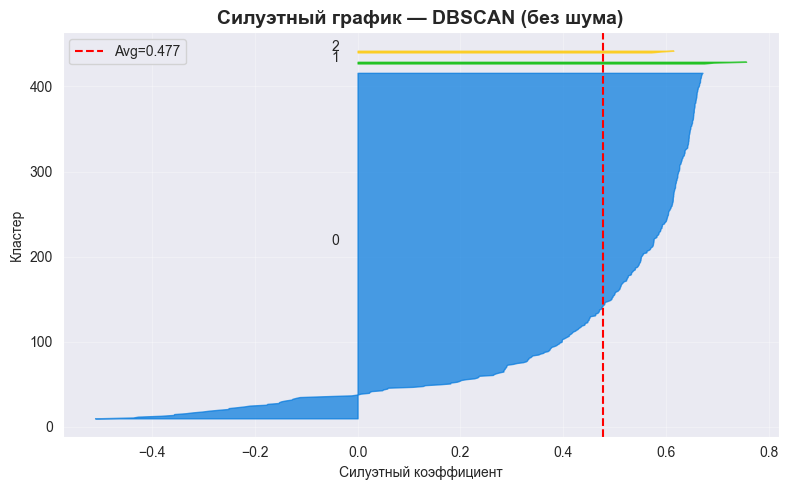

In [10]:
# Силуэтный график
valid_mask = labels != -1
lbl_valid  = labels[valid_mask]
X_valid    = X_scaled[valid_mask]
n_cl_valid = len(set(lbl_valid))

if n_cl_valid < 2:
    print(f"Недостаточно кластеров ({n_cl_valid}) — увеличьте eps или уменьшите min_samples")
else:
    sample_sil = silhouette_samples(X_valid, lbl_valid)
    plt.figure(figsize=(8, 5))
    y_lower = 10
    for i in sorted(set(lbl_valid)):
        vals = np.sort(sample_sil[lbl_valid == i])
        y_upper = y_lower + len(vals)
        color = cm.nipy_spectral(float(i+1) / (n_cl_valid+1))
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, color=color)
        plt.text(-0.05, y_lower + 0.5*len(vals), str(i))
        y_lower = y_upper + 10
    avg_sil = silhouette_score(X_valid, lbl_valid)
    plt.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg={avg_sil:.3f}')
    plt.title('Силуэтный график — DBSCAN (без шума)', fontsize=14, fontweight='bold')
    plt.xlabel('Силуэтный коэффициент'); plt.ylabel('Кластер')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()